In [1]:

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
data = load_breast_cancer()
X = data.data          # features (30 numeric measurements per tumor)
y = data.target        # labels: 0 = malignant, 1 = benign

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {dict(zip(*__import__('numpy').unique(y, return_counts=True)))}")
print(f"Class names: {data.target_names}\n")

Dataset shape: (569, 30)
Class distribution: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}
Class names: ['malignant' 'benign']



In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}\n")

Train size: 455 | Test size: 114



In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [6]:
y_pred = model.predict(X_test_scaled)

In [7]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("=" * 40)
print("EVALUATION RESULTS")
print("=" * 40)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nFull classification report (per-class breakdown):")
print(classification_report(y_test, y_pred, target_names=data.target_names))

EVALUATION RESULTS
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-score : 0.9861

Confusion Matrix:
[[41  1]
 [ 1 71]]

Full classification report (per-class breakdown):
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Text(0.5, 1.0, 'Confusion Matrix - Breast Cancer Classification')

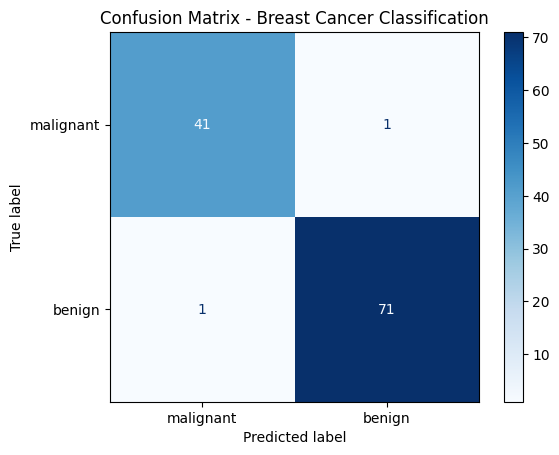

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Breast Cancer Classification")